In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [16]:
train_url = 'https://github.com/robitussin/CCMACLRL_EXAM/blob/ebd51da1dafde093c18d9e8f35c834d91b2887f7/datasets/train.csv?raw=true'
traindata = pd.read_csv(train_url)

In [17]:
traindata.columns = traindata.columns.str.strip()

In [18]:
traindata = traindata.drop("id", axis=1)

print("Train Shape:", traindata.shape)
print(traindata.info())
print(traindata.head())

Train Shape: (1117957, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 21 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   MonsoonIntensity                 1117957 non-null  int64  
 1   TopographyDrainage               1117957 non-null  int64  
 2   RiverManagement                  1117957 non-null  int64  
 3   Deforestation                    1117957 non-null  int64  
 4   Urbanization                     1117957 non-null  int64  
 5   ClimateChange                    1117957 non-null  int64  
 6   DamsQuality                      1117957 non-null  int64  
 7   Siltation                        1117957 non-null  int64  
 8   AgriculturalPractices            1117957 non-null  int64  
 9   Encroachments                    1117957 non-null  int64  
 10  IneffectiveDisasterPreparedness  1117957 non-null  int64  
 11  DrainageSystems        

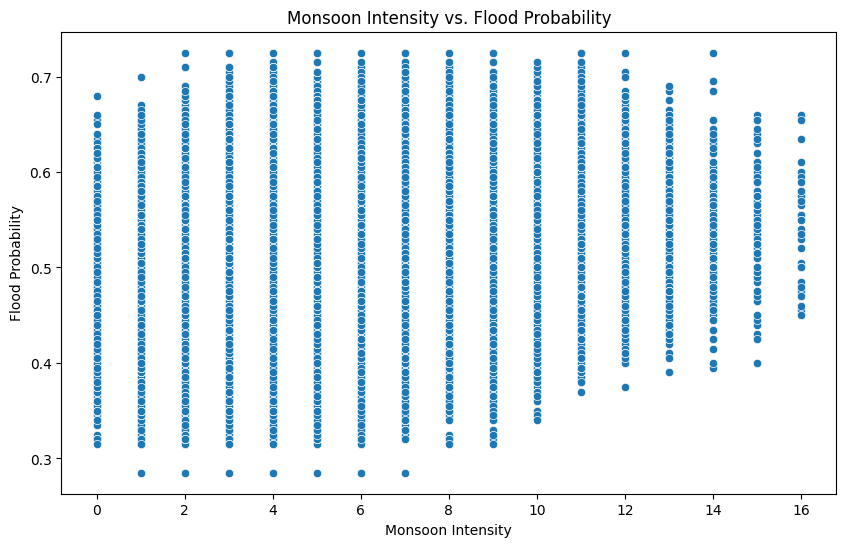

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=traindata['MonsoonIntensity'], y=traindata['FloodProbability'])
plt.title('Monsoon Intensity vs. Flood Probability')
plt.xlabel('Monsoon Intensity')
plt.ylabel('Flood Probability')
plt.show()

In [19]:
test_url = 'https://github.com/robitussin/CCMACLRL_EXAM/blob/ebd51da1dafde093c18d9e8f35c834d91b2887f7/datasets/test.csv?raw=true'
testdata = pd.read_csv(test_url)
testdata = testdata.drop("id", axis=1)

print("Test Shape:", testdata.shape)
print(testdata.info())
print(testdata.head())

Test Shape: (745305, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745305 entries, 0 to 745304
Data columns (total 20 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   MonsoonIntensity                 745305 non-null  int64
 1   TopographyDrainage               745305 non-null  int64
 2   RiverManagement                  745305 non-null  int64
 3   Deforestation                    745305 non-null  int64
 4   Urbanization                     745305 non-null  int64
 5   ClimateChange                    745305 non-null  int64
 6   DamsQuality                      745305 non-null  int64
 7   Siltation                        745305 non-null  int64
 8   AgriculturalPractices            745305 non-null  int64
 9   Encroachments                    745305 non-null  int64
 10  IneffectiveDisasterPreparedness  745305 non-null  int64
 11  DrainageSystems                  745305 non-null  int64
 12  Coast

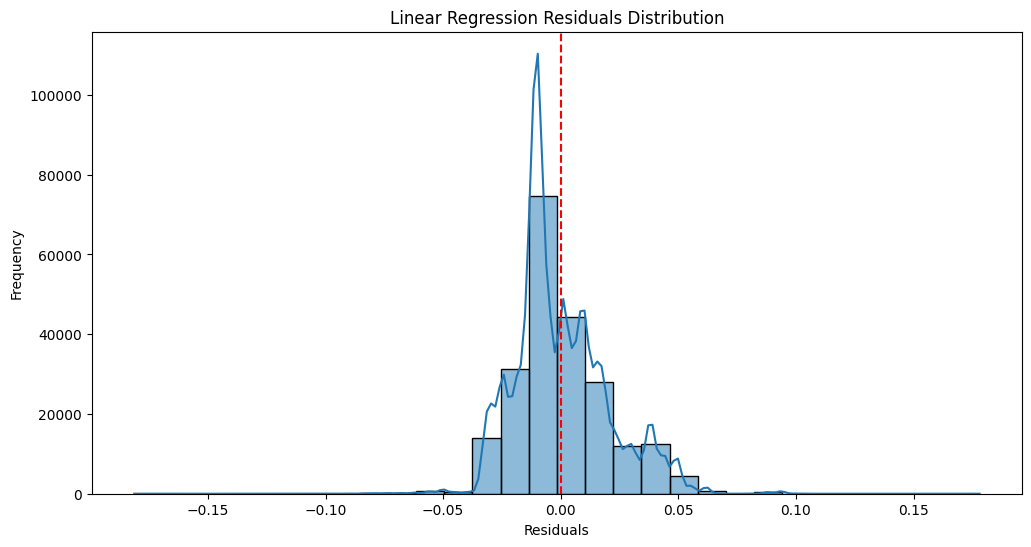

In [30]:
residuals = y_test - y_pred
plt.figure(figsize=(12, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Linear Regression Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.show()

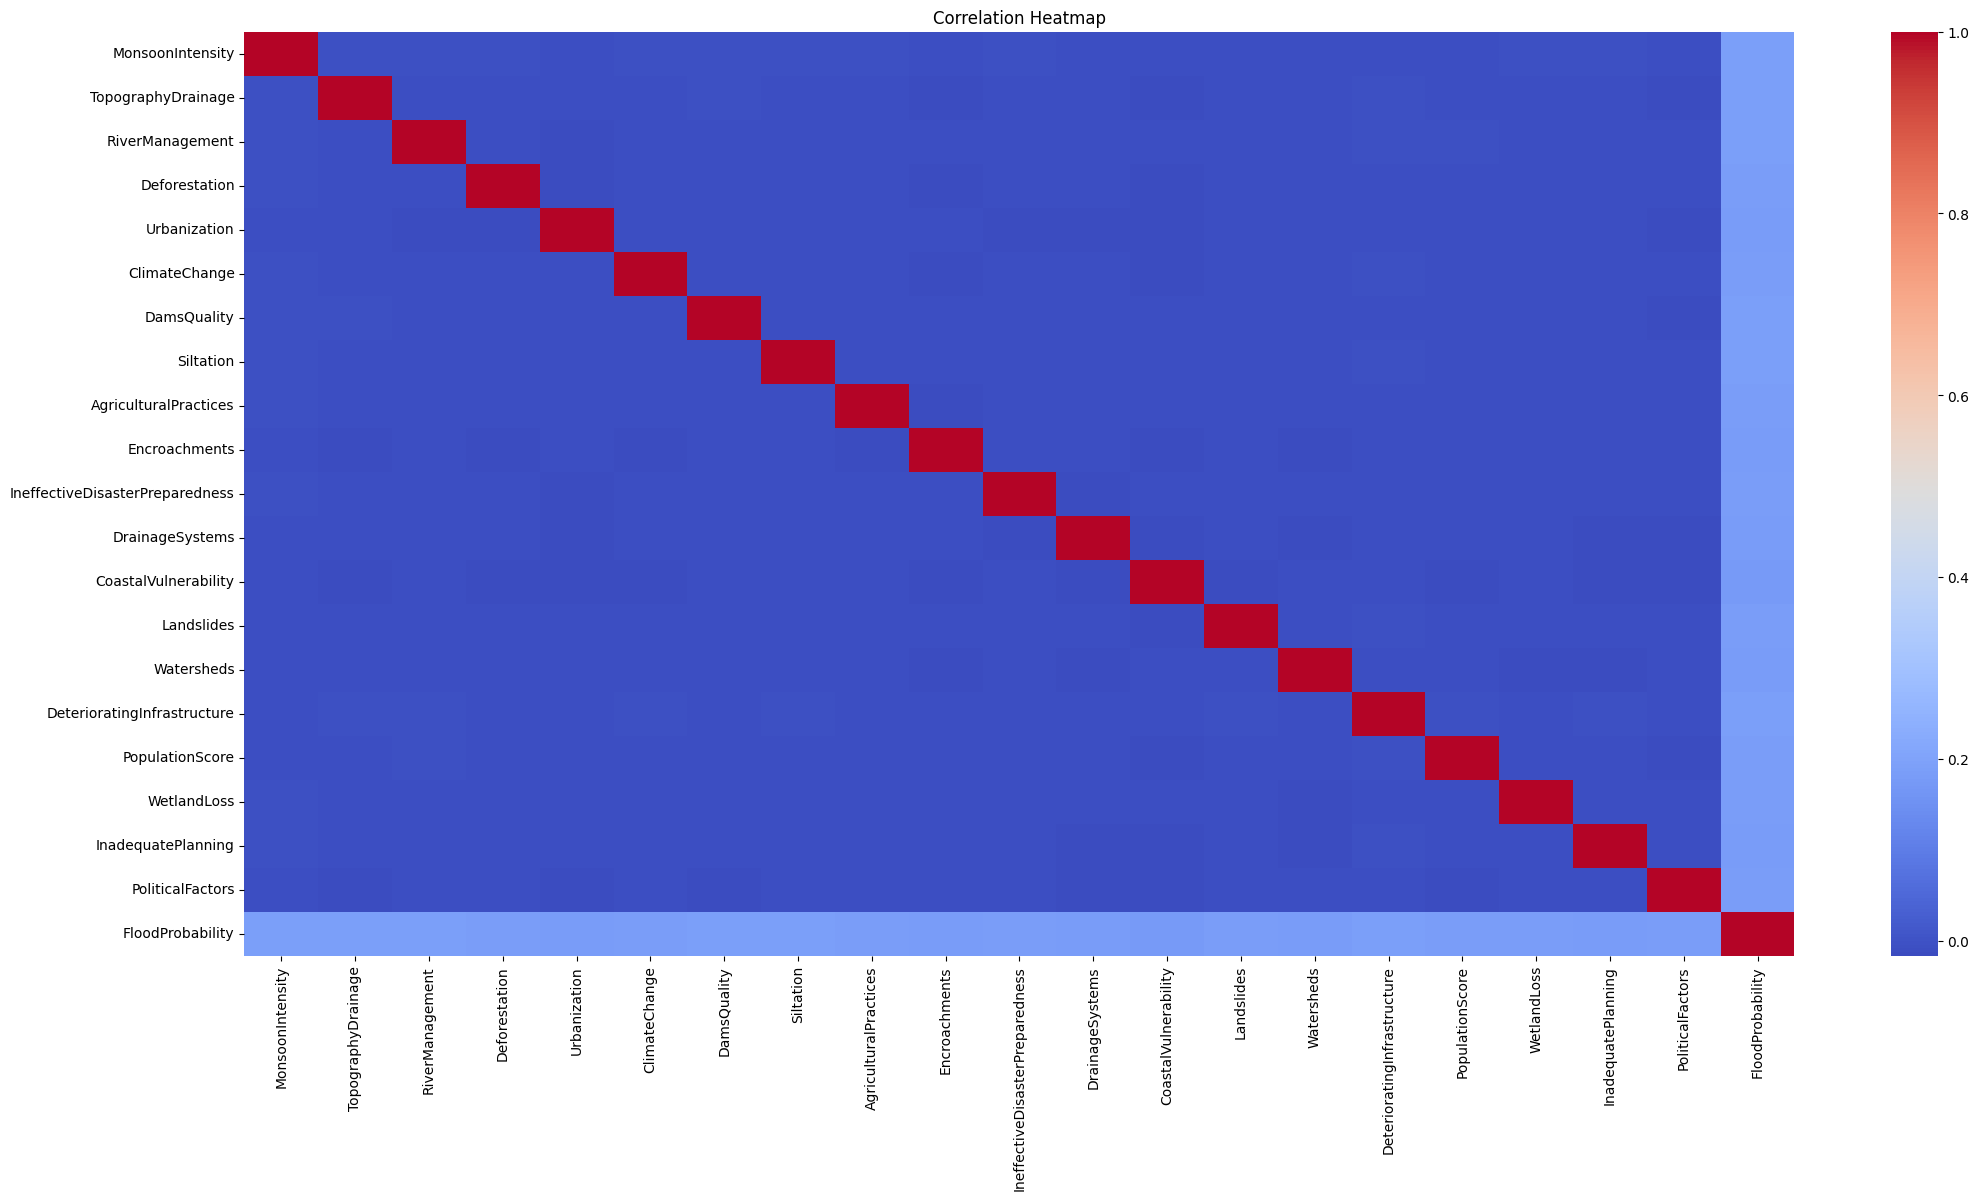

In [20]:
corr = traindata.corr(numeric_only=True)
plt.figure(figsize=(25, 12))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
X = traindata.drop('FloodProbability', axis=1)
y = traindata['FloodProbability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

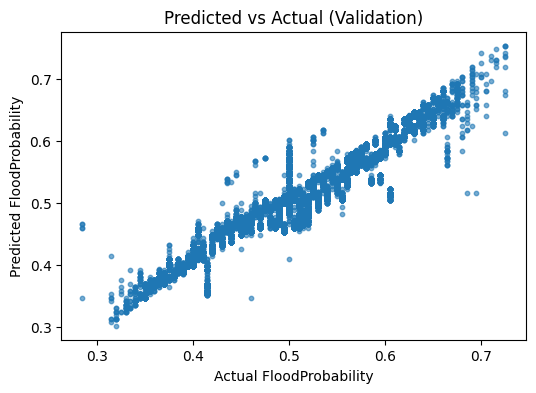

In [24]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, s=10, alpha=0.6)
plt.xlabel("Actual FloodProbability")
plt.ylabel("Predicted FloodProbability")
plt.title("Predicted vs Actual (Validation)")
plt.show()

In [25]:
model.fit(X, y)

LinearRegression()

In [26]:
test_pred = model.predict(testdata)

In [32]:
sample_url = 'https://github.com/robitussin/CCMACLRL_EXAM/blob/ebd51da1dafde093c18d9e8f35c834d91b2887f7/datasets/sample_submission.csv?raw=true'
samplefile = pd.read_csv(sample_url)

submission = pd.DataFrame({
    'id': samplefile['id'],
    'FloodProbability': test_pred
})

submission.to_csv('submission.csv', index=False)
print("Submission file created: submission.csv")
print(submission.head())

Submission file created: submission.csv
        id  FloodProbability
0  1117957          0.573615
1  1117958          0.455243
2  1117959          0.454742
3  1117960          0.466204
4  1117961          0.466068
